# Saved V5 Kaplan–Meier results and VECM comparison

This notebook assumes the V5 Kaplan–Meier processing has already completed and the monthly KM grids are saved.

It therefore starts from:

```python
load_monthly_km(...)
```

and does **not** rerun raw trade pulls, event extraction, or monthly aggregation.

The workflow:

1. loads the saved monthly KM grids for ETH linear and inverse perpetuals;
2. calculates the KM-estimated percentage reaching 90% basis resolution within 10 seconds;
3. graphs the monthly percentages with confidence intervals;
4. reads the saved VECM results using the same `read_files(...)` calls as the attached Hasbrouck notebook;
5. converts hourly VECM estimates to monthly summaries;
6. compares KM resolution with the responding market's error-correction coefficient and with information leadership;
7. repeats the comparison across VECM aggregation latencies;
8. saves analysis-ready CSV outputs.

## 1. Imports

In [1]:
from pathlib import Path
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.stats import pearsonr, spearmanr

from survival_analysis_basis_pipeline_v5 import load_monthly_km
from vecm_hasbrouck3 import *

pd.set_option("display.max_columns", 200)

## 2. Configuration

Set the four KM checkpoint directories to the directories already containing the saved V5 `km/` files.

`load_monthly_km(checkpoint_dir, first=...)` automatically reads the small saved monthly KM CSVs from `checkpoint_dir / "km"`.

In [2]:
# Existing V5 checkpoint directories
ETH_UM_DIR = Path("sa_eth_um")
ETH_CM_DIR = Path("sa_eth_cm")

KM_RESOLUTION_PCT = 90
KM_HORIZON_SECONDS = 10

# VECM settings copied from the attached notebook
VECM_START = datetime.datetime(2021, 1, 1)
VECM_END = datetime.datetime(2025, 12, 31)

VECM_AGGS = ["1s", "500ms", "200ms", "100ms", "50ms", "10ms"]
VECM_LAGS = [10]
VECM_INTERVAL = "1H"

VECM_PREFIX = "hasbrouck3_eth_alignedv2"
VECM_UM_FOLDER = r"C:\Users\Julia\Desktop\School files\4th year\Thesis\Thesis-code\vecm_hasbrouck3_eth_um"
VECM_CM_FOLDER = r"C:\Users\Julia\Desktop\School files\4th year\Thesis\Thesis-code\vecm_hasbrouck3_eth_cm"

PRIMARY_VECM_LATENCY = "10ms"
PRIMARY_VECM_LAG = 10
VECM_MONTHLY_AGGREGATION = "median"

## 3. Load the saved monthly KM grids

This is the only KM input step. No raw trades are downloaded or processed.

In [3]:
eth_um_km_spot = load_monthly_km(ETH_UM_DIR, first="spot")
eth_um_km_perp = load_monthly_km(ETH_UM_DIR, first="perp")

eth_cm_km_spot = load_monthly_km(ETH_CM_DIR, first="spot")
eth_cm_km_perp = load_monthly_km(ETH_CM_DIR, first="perp")

print("ETH linear spot KM rows:", len(eth_um_km_spot))
print("ETH linear perp KM rows:", len(eth_um_km_perp))
print("ETH inverse spot KM rows:", len(eth_cm_km_spot))
print("ETH inverse perp KM rows:", len(eth_cm_km_perp))

ETH linear spot KM rows: 21780
ETH linear perp KM rows: 21780
ETH inverse spot KM rows: 21780
ETH inverse perp KM rows: 21780


In [79]:
def label_km_frame(frame, contract_type, first):
    output = frame.copy()
    output["contract_type"] = contract_type

    if "first" not in output.columns:
        output["first"] = first

    return output


km_all = pd.concat(
    [
        label_km_frame(eth_um_km_spot, "linear", "spot"),
        label_km_frame(eth_um_km_perp, "linear", "perp"),
        label_km_frame(eth_cm_km_spot, "inverse", "spot"),
        label_km_frame(eth_cm_km_perp, "inverse", "perp"),
    ],
    ignore_index=True,
)

km_all.head()

,time_s,survival,ci_lower,ci_upper,period,first,shock_significance,resolution_pct,n_episodes,n_resolved,censoring_share,contract_type
0,0.0,1.000000,1.000000,1.000000,2021-01,spot,0.001,50,29828,28220,0.053909,linear
1,1.0,0.448270,0.442618,0.453905,2021-01,spot,0.001,50,29828,28220,0.053909,linear
2,2.0,0.339647,0.334276,0.345025,2021-01,spot,0.001,50,29828,28220,0.053909,linear
3,3.0,0.286811,0.281688,0.291953,2021-01,spot,0.001,50,29828,28220,0.053909,linear
4,4.0,0.253554,0.248630,0.258504,2021-01,spot,0.001,50,29828,28220,0.053909,linear


In [80]:
def extract_resolution_probability(
    km_grid,
    horizon_seconds=10.0,
    resolution_pct=90,
):
    required = {
        "period",
        "time_s",
        "survival",
        "ci_lower",
        "ci_upper",
    }
    missing = required.difference(km_grid.columns)

    if missing:
        raise ValueError(f"KM grid is missing columns: {sorted(missing)}")

    data = km_grid.copy()

    if "resolution_pct" in data.columns:
        data = data[
            data["resolution_pct"].astype(int).eq(int(resolution_pct))
        ].copy()

    data["time_s"] = pd.to_numeric(data["time_s"], errors="coerce")
    data = data.dropna(
        subset=["period", "time_s", "survival", "ci_lower", "ci_upper"]
    )

    group_columns = [
        column
        for column in [
            "period",
            "contract_type",
            "first",
            "shock_significance",
            "resolution_pct",
        ]
        if column in data.columns
    ]

    rows = []

    for group_key, group in data.groupby(
        group_columns,
        dropna=False,
        observed=True,
    ):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        group = group.sort_values("time_s")

        # KM is a right-continuous step function. Use the last saved estimate
        # at or before the requested horizon.
        eligible = group[group["time_s"] <= horizon_seconds]

        if eligible.empty:
            continue

        horizon_row = eligible.iloc[-1]
        survival = float(horizon_row["survival"])
        survival_lower = float(horizon_row["ci_lower"])
        survival_upper = float(horizon_row["ci_upper"])

        result = dict(zip(group_columns, group_key))
        result.update(
            {
                "horizon_seconds": float(horizon_seconds),
                "survival_at_horizon": survival,
                "resolved_share": 1.0 - survival,
                "resolved_ci_lower": 1.0 - survival_upper,
                "resolved_ci_upper": 1.0 - survival_lower,
                "resolved_percent": 100.0 * (1.0 - survival),
                "resolved_ci_lower_percent": 100.0 * (1.0 - survival_upper),
                "resolved_ci_upper_percent": 100.0 * (1.0 - survival_lower),
            }
        )

        for column in ["n_episodes", "n_resolved", "censoring_share"]:
            if column in group.columns:
                result[column] = horizon_row[column]

        rows.append(result)

    output = pd.DataFrame(rows)

    if not output.empty:
        output["period"] = output["period"].astype(str)
        output["month"] = pd.to_datetime(
            output["period"],
            format="%Y-%m",
            errors="coerce",
        )

    return output

In [81]:
km_10s = extract_resolution_probability(
    km_all,
    horizon_seconds=KM_HORIZON_SECONDS,
    resolution_pct=KM_RESOLUTION_PCT,
)

km_10s.sort_values(
    ["contract_type", "first", "month"]
).head(12)

,period,contract_type,first,shock_significance,resolution_pct,horizon_seconds,survival_at_horizon,resolved_share,resolved_ci_lower,resolved_ci_upper,resolved_percent,resolved_ci_lower_percent,resolved_ci_upper_percent,n_episodes,n_resolved,censoring_share,month
0,2021-01,inverse,perp,0.001,90,10.0,0.692516,0.307484,0.302752,0.312271,30.748352,30.275192,31.227144,36106,25527,0.292998,2021-01-01
4,2021-02,inverse,perp,0.001,90,10.0,0.577412,0.422588,0.418341,0.426861,42.258839,41.834112,42.686146,51646,42127,0.184312,2021-02-01
8,2021-03,inverse,perp,0.001,90,10.0,0.598548,0.401452,0.397402,0.405529,40.145241,39.740220,40.552878,55907,45515,0.185880,2021-03-01
12,2021-04,inverse,perp,0.001,90,10.0,0.535643,0.464357,0.460712,0.468016,46.435652,46.071166,46.801636,71626,60183,0.159760,2021-04-01
16,2021-05,inverse,perp,0.001,90,10.0,0.584313,0.415687,0.412681,0.418707,41.568715,41.268073,41.870695,102772,81959,0.202516,2021-05-01
20,2021-06,inverse,perp,0.001,90,10.0,0.605518,0.394482,0.390120,0.398875,39.448181,39.011975,39.887530,47878,37788,0.210744,2021-06-01
24,2021-07,inverse,perp,0.001,90,10.0,0.502191,0.497809,0.493075,0.502563,49.780892,49.307521,50.256287,42673,36535,0.143838,2021-07-01
28,2021-08,inverse,perp,0.001,90,10.0,0.422655,0.577345,0.573681,0.581015,57.734517,57.368071,58.101477,69707,62053,0.109802,2021-08-01
32,2021-09,inverse,perp,0.001,90,10.0,0.455244,0.544756,0.541148,0.548372,54.475609,54.114794,54.837199,73018,63951,0.124175,2021-09-01
36,2021-10,inverse,perp,0.001,90,10.0,0.431595,0.568405,0.564923,0.571893,56.840532,56.492293,57.189305,77589,69461,0.104757,2021-10-01


## 5. Graph the monthly percentage resolved within 10 seconds

In [82]:
def plot_resolution_within_horizon(
    resolution_summary,
    horizon_seconds=10,
    resolution_pct=90,
):
    data = resolution_summary.dropna(
        subset=[
            "month",
            "resolved_percent",
            "resolved_ci_lower_percent",
            "resolved_ci_upper_percent",
        ]
    ).copy()

    contract_types = [
        contract
        for contract in ["linear", "inverse"]
        if contract in data["contract_type"].unique()
    ]

    fig, axes = plt.subplots(
        len(contract_types),
        1,
        figsize=(12, 4.5 * len(contract_types)),
        sharex=True,
        squeeze=False,
    )

    for axis, contract_type in zip(axes[:, 0], contract_types):
        contract_data = data[
            data["contract_type"].eq(contract_type)
        ]

        for first, group in contract_data.groupby("first", observed=True):
            group = group.sort_values("month")

            line = axis.plot(
                group["month"],
                group["resolved_percent"],
                marker="o",
                markersize=3,
                linewidth=1.5,
                label=f"{first}-originating shocks",
            )[0]

            axis.fill_between(
                group["month"],
                group["resolved_ci_lower_percent"],
                group["resolved_ci_upper_percent"],
                alpha=0.15,
                color=line.get_color(),
            )

        axis.set_title(f"{contract_type.capitalize()} perpetual")
        axis.set_ylabel(f"Resolved within {horizon_seconds:g}s (%)")
        axis.set_ylim(0, 100)
        axis.grid(axis="y", alpha=0.3)
        axis.legend()

    axes[-1, 0].set_xlabel("Month")
    axes[-1, 0].xaxis.set_major_locator(mdates.YearLocator())
    axes[-1, 0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    fig.suptitle(
        f"KM-estimated share reaching {resolution_pct}% basis resolution "
        f"within {horizon_seconds:g} seconds",
        y=1.01,
    )

    fig.tight_layout()
    plt.show()

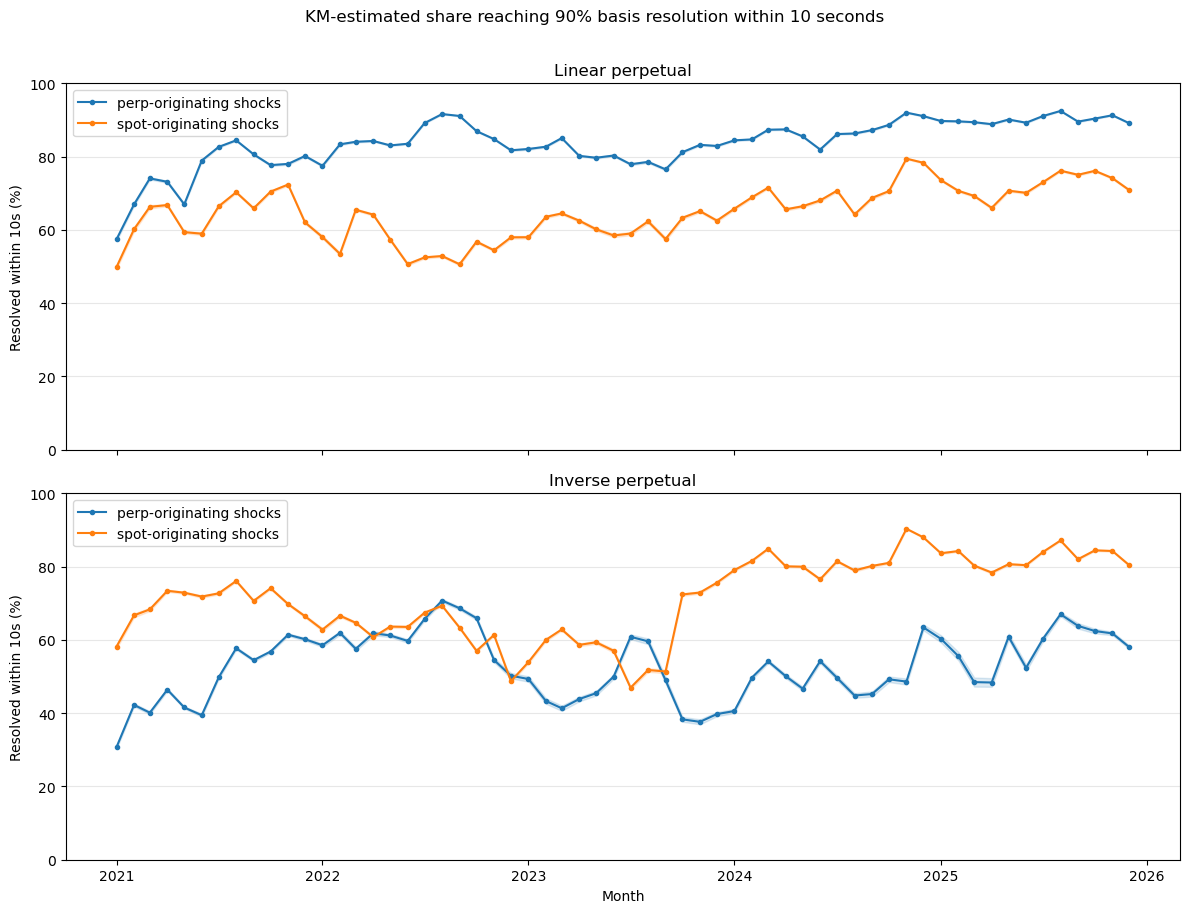

In [83]:
plot_resolution_within_horizon(
    km_10s,
    horizon_seconds=KM_HORIZON_SECONDS,
    resolution_pct=KM_RESOLUTION_PCT,
)

In [84]:
linear_res_dict = read_files(
    VECM_START,
    VECM_END,
    VECM_AGGS,
    VECM_INTERVAL,
    VECM_LAGS,
    "um",
    VECM_PREFIX,
    VECM_UM_FOLDER,
)

inverse_res_dict = read_files(
    VECM_START,
    VECM_END,
    VECM_AGGS,
    VECM_INTERVAL,
    VECM_LAGS,
    "cm",
    VECM_PREFIX,
    VECM_CM_FOLDER,
)

print("Linear result keys:", sorted(linear_res_dict.keys()))
print("Inverse result keys:", sorted(inverse_res_dict.keys()))

Linear result keys: [('100ms', 10), ('10ms', 10), ('1s', 10), ('200ms', 10), ('500ms', 10), ('50ms', 10)]
Inverse result keys: [('100ms', 10), ('10ms', 10), ('1s', 10), ('200ms', 10), ('500ms', 10), ('50ms', 10)]


## 7. Convert hourly VECM results to monthly values

The VECM files contain one row for `log_midpoint_spot` and one row for `log_midpoint_perp` in each hourly interval. The function below:

1. removes duplicate interval-series estimates, preferring the row with more observations;
2. pivots spot and perp estimates into one row;
3. takes the monthly median or mean.

The median is the default because hourly alpha and share estimates can contain extreme values.

## 6. Read the saved VECM results

These calls reproduce the VECM notebook's saved-result workflow.

In [85]:
linear_res_dict = read_files(
    VECM_START,
    VECM_END,
    VECM_AGGS,
    VECM_INTERVAL,
    VECM_LAGS,
    "um",
    VECM_PREFIX,
    VECM_UM_FOLDER,
)

inverse_res_dict = read_files(
    VECM_START,
    VECM_END,
    VECM_AGGS,
    VECM_INTERVAL,
    VECM_LAGS,
    "cm",
    VECM_PREFIX,
    VECM_CM_FOLDER,
)

print("Linear result keys:", sorted(linear_res_dict.keys()))
print("Inverse result keys:", sorted(inverse_res_dict.keys()))

Linear result keys: [('100ms', 10), ('10ms', 10), ('1s', 10), ('200ms', 10), ('500ms', 10), ('50ms', 10)]
Inverse result keys: [('100ms', 10), ('10ms', 10), ('1s', 10), ('200ms', 10), ('500ms', 10), ('50ms', 10)]


In [86]:
def prepare_monthly_vecm_results(
    results_dict,
    contract_type,
    latency,
    lag_base=10,
    monthly_aggregation="median",
):
    key = (latency, lag_base)

    if key not in results_dict:
        raise KeyError(
            f"{key} was not found. Available keys: "
            f"{sorted(results_dict.keys())}"
        )

    raw = results_dict[key].copy()
    raw["interval"] = pd.to_datetime(raw["interval"], errors="coerce")
    raw = raw.dropna(subset=["interval"])

    expected_series = {
        "log_midpoint_spot",
        "log_midpoint_perp",
    }
    actual_series = set(raw["series"].dropna().astype(str).unique())
    missing_series = expected_series.difference(actual_series)

    if missing_series:
        raise ValueError(
            f"Missing VECM series: {sorted(missing_series)}. "
            f"Observed series include: {sorted(actual_series)}"
        )

    duplicate_keys = ["interval", "series"]

    if "n_obs" in raw.columns:
        raw = (
            raw.sort_values(
                duplicate_keys + ["n_obs"],
                ascending=[True, True, False],
            )
            .drop_duplicates(duplicate_keys, keep="first")
        )
    else:
        raw = raw.drop_duplicates(duplicate_keys, keep="first")

    value_columns = [
        column
        for column in [
            "alpha",
            "CS",
            "HIS_lower",
            "HIS_upper",
            "HIS_mid",
            "ILS_mid",
            "n_obs",
        ]
        if column in raw.columns
    ]

    wide = raw.pivot_table(
        index="interval",
        columns="series",
        values=value_columns,
        aggfunc="first",
    )

    wide.columns = [
        f"{metric}_{series.replace('log_midpoint_', '')}"
        for metric, series in wide.columns
    ]
    wide = wide.reset_index()

    wide["month"] = wide["interval"].dt.to_period("M").dt.to_timestamp()
    wide["period"] = wide["month"].dt.strftime("%Y-%m")
    wide["contract_type"] = contract_type
    wide["latency"] = latency
    wide["lag_base"] = lag_base

    identifier_columns = {
        "interval",
        "month",
        "period",
        "contract_type",
        "latency",
        "lag_base",
    }
    numeric_columns = [
        column
        for column in wide.columns
        if column not in identifier_columns
    ]

    grouped = wide.groupby(
        ["period", "month", "contract_type", "latency", "lag_base"],
        as_index=False,
        observed=True,
    )[numeric_columns]

    if monthly_aggregation == "median":
        monthly = grouped.median()
    elif monthly_aggregation == "mean":
        monthly = grouped.mean()
    else:
        raise ValueError(
            "monthly_aggregation must be 'median' or 'mean'."
        )

    if "ILS_mid_spot" in monthly.columns:
        monthly["ILS_spot"] = monthly["ILS_mid_spot"]

    if "ILS_mid_perp" in monthly.columns:
        monthly["ILS_perp"] = monthly["ILS_mid_perp"]

    if "alpha_spot" in monthly.columns:
        monthly["abs_alpha_spot"] = monthly["alpha_spot"].abs()

    if "alpha_perp" in monthly.columns:
        monthly["abs_alpha_perp"] = monthly["alpha_perp"].abs()

    return monthly

In [87]:
vecm_linear_primary = prepare_monthly_vecm_results(
    linear_res_dict,
    contract_type="linear",
    latency=PRIMARY_VECM_LATENCY,
    lag_base=PRIMARY_VECM_LAG,
    monthly_aggregation=VECM_MONTHLY_AGGREGATION,
)

vecm_inverse_primary = prepare_monthly_vecm_results(
    inverse_res_dict,
    contract_type="inverse",
    latency=PRIMARY_VECM_LATENCY,
    lag_base=PRIMARY_VECM_LAG,
    monthly_aggregation=VECM_MONTHLY_AGGREGATION,
)

vecm_monthly_primary = pd.concat(
    [vecm_linear_primary, vecm_inverse_primary],
    ignore_index=True,
)

vecm_monthly_primary.head()

,period,month,contract_type,latency,lag_base,CS_perp,CS_spot,HIS_lower_perp,HIS_lower_spot,HIS_mid_perp,HIS_mid_spot,HIS_upper_perp,HIS_upper_spot,ILS_mid_perp,ILS_mid_spot,alpha_perp,alpha_spot,n_obs_perp,n_obs_spot,ILS_spot,ILS_perp,abs_alpha_spot,abs_alpha_perp
0,2021-01,2021-01-01,linear,10ms,10,0.695908,0.304092,0.770378,0.229621,0.793647,0.206353,0.816439,0.183561,0.623800,0.376200,0.004298,-0.010761,60114.5,60114.5,0.376200,0.623800,0.010761,0.004298
1,2021-02,2021-02-01,linear,10ms,10,0.633229,0.366771,0.644140,0.355860,0.669422,0.330578,0.694284,0.305716,0.542188,0.457812,0.003512,-0.006074,49843.0,49843.0,0.457812,0.542188,0.006074,0.003512
2,2021-03,2021-03-01,linear,10ms,10,0.681116,0.318884,0.702927,0.297073,0.728131,0.271869,0.754800,0.245200,0.557472,0.442528,0.005102,-0.011331,41321.0,41321.0,0.442528,0.557472,0.011331,0.005102
3,2021-04,2021-04-01,linear,10ms,10,0.658667,0.341333,0.702127,0.297873,0.725624,0.274376,0.746866,0.253134,0.570968,0.429032,0.003587,-0.007367,51135.0,51135.0,0.429032,0.570968,0.007367,0.003587
4,2021-05,2021-05-01,linear,10ms,10,0.686466,0.313534,0.763924,0.236076,0.789218,0.210782,0.814069,0.185931,0.624334,0.375666,0.003583,-0.007486,84945.0,84945.0,0.375666,0.624334,0.007486,0.003583


## 8. Merge KM and VECM results

For a spot-originating shock, the responding market is the perpetual market, so the corresponding VECM adjustment coefficient is `alpha_perp`.

For a perp-originating shock, the responding market is spot, so the corresponding coefficient is `alpha_spot`.

In [88]:
comparison_primary = km_10s.merge(
    vecm_monthly_primary,
    on=["period", "month", "contract_type"],
    how="inner",
    validate="many_to_one",
)

comparison_primary["responding_alpha"] = np.where(
    comparison_primary["first"].eq("spot"),
    comparison_primary["alpha_perp"],
    comparison_primary["alpha_spot"],
)

comparison_primary["abs_responding_alpha"] = (
    comparison_primary["responding_alpha"].abs()
)

if {"ILS_spot", "ILS_perp"}.issubset(comparison_primary.columns):
    comparison_primary["origin_market_ILS"] = np.where(
        comparison_primary["first"].eq("spot"),
        comparison_primary["ILS_spot"],
        comparison_primary["ILS_perp"],
    )

    comparison_primary["responding_market_ILS"] = np.where(
        comparison_primary["first"].eq("spot"),
        comparison_primary["ILS_perp"],
        comparison_primary["ILS_spot"],
    )

comparison_primary.head()

,period,contract_type,first,shock_significance,resolution_pct,horizon_seconds,survival_at_horizon,resolved_share,resolved_ci_lower,resolved_ci_upper,resolved_percent,resolved_ci_lower_percent,resolved_ci_upper_percent,n_episodes,n_resolved,censoring_share,month,latency,lag_base,CS_perp,CS_spot,HIS_lower_perp,HIS_lower_spot,HIS_mid_perp,HIS_mid_spot,HIS_upper_perp,HIS_upper_spot,ILS_mid_perp,ILS_mid_spot,alpha_perp,alpha_spot,n_obs_perp,n_obs_spot,ILS_spot,ILS_perp,abs_alpha_spot,abs_alpha_perp,responding_alpha,abs_responding_alpha,origin_market_ILS,responding_market_ILS
0,2021-01,inverse,perp,0.001,90,10.0,0.692516,0.307484,0.302752,0.312271,30.748352,30.275192,31.227144,36106,25527,0.292998,2021-01-01,10ms,10,0.489768,0.510232,0.266334,0.733666,0.290637,0.709363,0.318234,0.681766,0.298259,0.701741,0.010285,-0.009920,36177.0,36177.0,0.701741,0.298259,0.009920,0.010285,-0.009920,0.009920,0.298259,0.701741
1,2021-01,inverse,spot,0.001,90,10.0,0.417963,0.582037,0.576445,0.587640,58.203701,57.644536,58.763963,29828,26591,0.108522,2021-01-01,10ms,10,0.489768,0.510232,0.266334,0.733666,0.290637,0.709363,0.318234,0.681766,0.298259,0.701741,0.010285,-0.009920,36177.0,36177.0,0.701741,0.298259,0.009920,0.010285,0.010285,0.010285,0.701741,0.298259
2,2021-01,linear,perp,0.001,90,10.0,0.425738,0.574262,0.569838,0.578693,57.426156,56.983783,57.869317,47905,41697,0.129590,2021-01-01,10ms,10,0.695908,0.304092,0.770378,0.229621,0.793647,0.206353,0.816439,0.183561,0.623800,0.376200,0.004298,-0.010761,60114.5,60114.5,0.376200,0.623800,0.010761,0.004298,-0.010761,0.010761,0.623800,0.376200
3,2021-01,linear,spot,0.001,90,10.0,0.501576,0.498424,0.492765,0.504113,49.842430,49.276468,50.411276,29828,23512,0.211747,2021-01-01,10ms,10,0.695908,0.304092,0.770378,0.229621,0.793647,0.206353,0.816439,0.183561,0.623800,0.376200,0.004298,-0.010761,60114.5,60114.5,0.376200,0.623800,0.010761,0.004298,0.004298,0.004298,0.376200,0.623800
4,2021-02,inverse,perp,0.001,90,10.0,0.577412,0.422588,0.418341,0.426861,42.258839,41.834112,42.686146,51646,42127,0.184312,2021-02-01,10ms,10,0.496450,0.503550,0.223540,0.776460,0.243559,0.756441,0.262735,0.737265,0.249137,0.750863,0.004898,-0.005089,32644.5,32644.5,0.750863,0.249137,0.005089,0.004898,-0.005089,0.005089,0.249137,0.750863


## 9. Plot KM resolution against the responding market's error-correction coefficient

In [89]:
def plot_km_vs_error_correction(comparison):
    comparison = comparison[
        (
            comparison["first"].eq("spot")
            & comparison["alpha_perp"].gt(0)
        )
        |
        (
            comparison["first"].eq("perp")
            & comparison["alpha_spot"].lt(0)
        )
    ].copy()
    data = comparison.dropna(
        subset=["abs_responding_alpha", "resolved_percent"]
    ).copy()

    contract_types = [
        contract
        for contract in ["linear", "inverse"]
        if contract in data["contract_type"].unique()
    ]

    fig, axes = plt.subplots(
        1,
        len(contract_types),
        figsize=(6 * len(contract_types), 5),
        squeeze=False,
    )

    for axis, contract_type in zip(axes[0], contract_types):
        contract_data = data[
            data["contract_type"].eq(contract_type)
        ]

        for first, group in contract_data.groupby("first", observed=True):
            axis.scatter(
                group["abs_responding_alpha"],
                group["resolved_percent"],
                alpha=0.65,
                label=f"{first}-originating",
            )

            valid = group[
                ["abs_responding_alpha", "resolved_percent"]
            ].dropna()

            if len(valid) >= 3:
                slope, intercept = np.polyfit(
                    valid["abs_responding_alpha"],
                    valid["resolved_percent"],
                    1,
                )

                x_values = np.linspace(
                    valid["abs_responding_alpha"].min(),
                    valid["abs_responding_alpha"].max(),
                    100,
                )

                axis.plot(
                    x_values,
                    intercept + slope * x_values,
                    linewidth=1.5,
                )

        axis.set_title(f"{contract_type.capitalize()} perpetual")
        axis.set_xlabel("Absolute responding-market alpha")
        axis.set_ylabel("Resolved within 10 seconds (%)")
        axis.set_ylim(0, 100)
        axis.grid(alpha=0.3)
        axis.legend()

    fig.suptitle(
        f"Basis resolution versus VECM error correction "
        f"({PRIMARY_VECM_LATENCY}, lag base {PRIMARY_VECM_LAG})",
        y=1.02,
    )
    fig.tight_layout()
    plt.show()

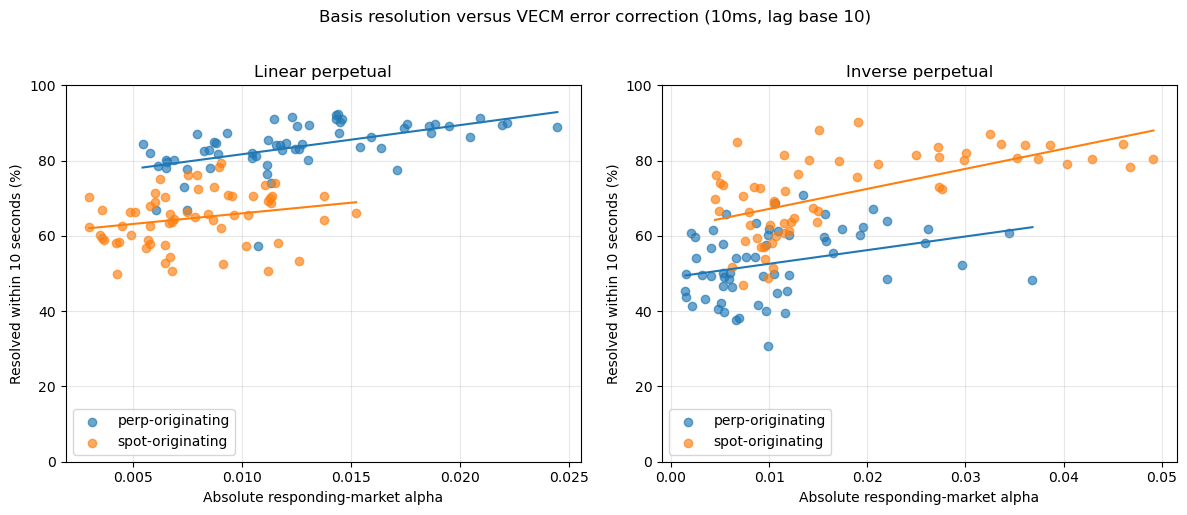

In [90]:
plot_km_vs_error_correction(comparison_primary)

## 10. Correlation summary

Spearman correlation is the preferred descriptive measure here because the monthly relationship may be nonlinear and the estimates may contain outliers. Pearson correlation is included for comparison.

These correlations are descriptive associations, not causal estimates.

In [91]:
def correlation_summary(comparison):
    rows = []

    group_columns = [
        column
        for column in ["contract_type", "first", "latency"]
        if column in comparison.columns
    ]

    for group_key, group in comparison.groupby(
        group_columns,
        observed=True,
    ):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        valid = group[
            ["abs_responding_alpha", "resolved_share"]
        ].replace([np.inf, -np.inf], np.nan).dropna()

        if len(valid) < 3:
            continue

        pearson_r, pearson_p = pearsonr(
            valid["abs_responding_alpha"],
            valid["resolved_share"],
        )

        spearman_rho, spearman_p = spearmanr(
            valid["abs_responding_alpha"],
            valid["resolved_share"],
        )

        row = dict(zip(group_columns, group_key))
        row.update(
            {
                "n_months": len(valid),
                "pearson_r": pearson_r,
                "pearson_p": pearson_p,
                "spearman_rho": spearman_rho,
                "spearman_p": spearman_p,
            }
        )
        rows.append(row)

    return pd.DataFrame(rows)

In [92]:
primary_alpha_correlations = correlation_summary(comparison_primary)
primary_alpha_correlations

,contract_type,first,latency,n_months,pearson_r,pearson_p,spearman_rho,spearman_p
0,inverse,perp,10ms,60,0.323749,1.162417e-02,0.370325,3.585427e-03
1,inverse,spot,10ms,60,0.608535,2.495087e-07,0.614171,1.798113e-07
2,linear,perp,10ms,60,0.541410,7.938774e-06,0.654404,1.420407e-08
3,linear,spot,10ms,60,0.230033,7.703711e-02,0.273298,3.461518e-02


## 11. Compare KM resolution with information leadership

ILS measures leadership rather than convergence speed, so this should be treated as a secondary comparison.

In [93]:
def plot_km_vs_origin_leadership(comparison):
    required = {"origin_market_ILS", "resolved_percent"}
    missing = required.difference(comparison.columns)

    if missing:
        raise ValueError(
            f"Comparison frame is missing columns: {sorted(missing)}"
        )

    data = comparison.dropna(
        subset=["origin_market_ILS", "resolved_percent"]
    ).copy()

    contract_types = [
        contract
        for contract in ["linear", "inverse"]
        if contract in data["contract_type"].unique()
    ]

    fig, axes = plt.subplots(
        1,
        len(contract_types),
        figsize=(6 * len(contract_types), 5),
        squeeze=False,
    )

    for axis, contract_type in zip(axes[0], contract_types):
        contract_data = data[
            data["contract_type"].eq(contract_type)
        ]

        for first, group in contract_data.groupby("first", observed=True):
            axis.scatter(
                group["origin_market_ILS"],
                group["resolved_percent"],
                alpha=0.65,
                label=f"{first}-originating",
            )

        axis.axvline(0.5, linestyle="--", alpha=0.6)
        axis.set_title(f"{contract_type.capitalize()} perpetual")
        axis.set_xlabel("ILS of shock-origin market")
        axis.set_ylabel("Resolved within 10 seconds (%)")
        axis.set_xlim(0, 1)
        axis.set_ylim(0, 100)
        axis.grid(alpha=0.3)
        axis.legend()

    fig.suptitle(
        "Basis resolution versus information leadership",
        y=1.02,
    )
    fig.tight_layout()
    plt.show()

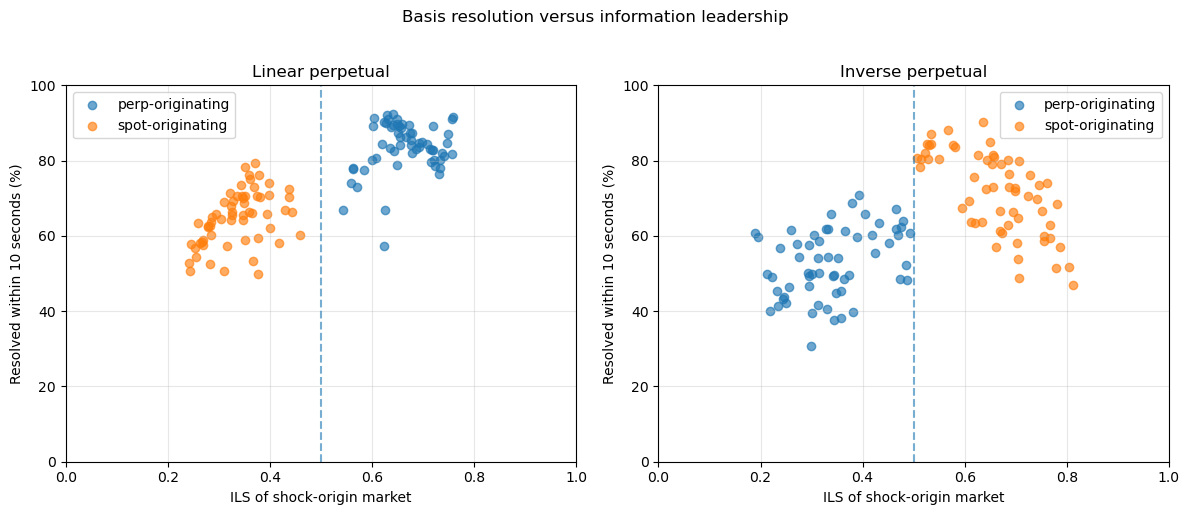

In [94]:
if "origin_market_ILS" in comparison_primary.columns:
    plot_km_vs_origin_leadership(comparison_primary)
else:
    print("ILS columns were not found in the selected VECM results.")

## 12. Repeat the alpha comparison across every VECM aggregation latency

In [95]:
vecm_frames = []

for latency in VECM_AGGS:
    key = (latency, PRIMARY_VECM_LAG)

    if key in linear_res_dict:
        vecm_frames.append(
            prepare_monthly_vecm_results(
                linear_res_dict,
                contract_type="linear",
                latency=latency,
                lag_base=PRIMARY_VECM_LAG,
                monthly_aggregation=VECM_MONTHLY_AGGREGATION,
            )
        )

    if key in inverse_res_dict:
        vecm_frames.append(
            prepare_monthly_vecm_results(
                inverse_res_dict,
                contract_type="inverse",
                latency=latency,
                lag_base=PRIMARY_VECM_LAG,
                monthly_aggregation=VECM_MONTHLY_AGGREGATION,
            )
        )

vecm_monthly_all = pd.concat(vecm_frames, ignore_index=True)

comparison_all_latencies = km_10s.merge(
    vecm_monthly_all,
    on=["period", "month", "contract_type"],
    how="inner",
)

comparison_all_latencies["responding_alpha"] = np.where(
    comparison_all_latencies["first"].eq("spot"),
    comparison_all_latencies["alpha_perp"],
    comparison_all_latencies["alpha_spot"],
)

comparison_all_latencies["abs_responding_alpha"] = (
    comparison_all_latencies["responding_alpha"].abs()
)

latency_alpha_correlations = correlation_summary(
    comparison_all_latencies
)

latency_alpha_correlations.sort_values(
    ["contract_type", "first", "latency"]
)

,contract_type,first,latency,n_months,pearson_r,pearson_p,spearman_rho,spearman_p
0,inverse,perp,100ms,60,0.285824,2.684161e-02,0.317088,1.356610e-02
1,inverse,perp,10ms,60,0.323749,1.162417e-02,0.370325,3.585427e-03
2,inverse,perp,1s,60,0.218497,9.350409e-02,0.198500,1.284103e-01
3,inverse,perp,200ms,60,0.252629,5.148611e-02,0.272353,3.527055e-02
4,inverse,perp,500ms,60,0.233139,7.302193e-02,0.240011,6.473120e-02
5,inverse,perp,50ms,60,0.294919,2.216559e-02,0.317088,1.356610e-02
6,inverse,spot,100ms,60,0.606071,2.873600e-07,0.613337,1.888146e-07
7,inverse,spot,10ms,60,0.608535,2.495087e-07,0.614171,1.798113e-07
8,inverse,spot,1s,60,0.596400,4.945740e-07,0.567602,2.252463e-06
9,inverse,spot,200ms,60,0.598908,4.303613e-07,0.589330,7.274274e-07


## 13. Optional robustness: other clock-time horizons

The 10-second horizon is the primary comparison because it corresponds to the maximum short-run VECM lag span. This cell calculates the same KM summary at additional horizons without refitting the survival models.

In [96]:
ROBUSTNESS_HORIZONS = [1, 5, 10, 30, 60, 120]

km_horizon_summaries = []

for horizon in ROBUSTNESS_HORIZONS:
    summary = extract_resolution_probability(
        km_all,
        horizon_seconds=horizon,
        resolution_pct=KM_RESOLUTION_PCT,
    )
    km_horizon_summaries.append(summary)

km_all_horizons = pd.concat(
    km_horizon_summaries,
    ignore_index=True,
)

km_all_horizons.head()

,period,contract_type,first,shock_significance,resolution_pct,horizon_seconds,survival_at_horizon,resolved_share,resolved_ci_lower,resolved_ci_upper,resolved_percent,resolved_ci_lower_percent,resolved_ci_upper_percent,n_episodes,n_resolved,censoring_share,month
0,2021-01,inverse,perp,0.001,90,1.0,0.948347,0.051653,0.049419,0.053986,5.165346,4.941895,5.398612,36106,25527,0.292998,2021-01-01
1,2021-01,inverse,spot,0.001,90,1.0,0.858824,0.141176,0.137275,0.145179,14.117608,13.727482,14.517862,29828,26591,0.108522,2021-01-01
2,2021-01,linear,perp,0.001,90,1.0,0.864294,0.135706,0.132671,0.138805,13.570608,13.267096,13.880495,47905,41697,0.129590,2021-01-01
3,2021-01,linear,spot,0.001,90,1.0,0.852622,0.147378,0.143405,0.151451,14.737830,14.340519,15.145148,29828,23512,0.211747,2021-01-01
4,2021-02,inverse,perp,0.001,90,1.0,0.899043,0.100957,0.098390,0.103587,10.095651,9.838953,10.358655,51646,42127,0.184312,2021-02-01


## 14. Save the analysis-ready outputs

In [97]:
OUTPUT_DIR = Path("sa_results/km_v5_vecm_comparison")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

km_10s.to_csv(
    OUTPUT_DIR / "km_resolved_within_10s.csv",
    index=False,
)

km_all_horizons.to_csv(
    OUTPUT_DIR / "km_resolution_multiple_horizons.csv",
    index=False,
)

vecm_monthly_primary.to_csv(
    OUTPUT_DIR
    / f"vecm_monthly_{PRIMARY_VECM_LATENCY}_lag{PRIMARY_VECM_LAG}.csv",
    index=False,
)

comparison_primary.to_csv(
    OUTPUT_DIR
    / f"km_vecm_comparison_{PRIMARY_VECM_LATENCY}_lag{PRIMARY_VECM_LAG}.csv",
    index=False,
)

primary_alpha_correlations.to_csv(
    OUTPUT_DIR
    / f"km_vecm_alpha_correlations_{PRIMARY_VECM_LATENCY}_lag{PRIMARY_VECM_LAG}.csv",
    index=False,
)

comparison_all_latencies.to_csv(
    OUTPUT_DIR / "km_vecm_comparison_all_latencies.csv",
    index=False,
)

latency_alpha_correlations.to_csv(
    OUTPUT_DIR / "km_vecm_alpha_correlations_all_latencies.csv",
    index=False,
)

print("Saved outputs to:", OUTPUT_DIR.resolve())

Saved outputs to: C:\Users\Julia\OneDrive - University of Toronto\Desktop\School files\4th year\Thesis\Thesis-code\sa_results\km_v5_vecm_comparison


## Interpretation template

A careful paper interpretation is:

> For each month, we estimate the Kaplan–Meier probability that a shock-induced basis displacement reaches 90% resolution within 10 seconds. We compare this probability with the monthly median magnitude of the VECM error-correction coefficient for the market responding to the shock. The 10-second horizon corresponds to the maximum short-run lag span included in the VECM; it does not imply that VECM adjustment must be completed within 10 seconds.

A positive relationship between `resolved_share` and `abs_responding_alpha` would indicate that periods with stronger estimated error correction also tend to have a larger proportion of shock-induced dislocations resolve within the common 10-second horizon.